In [2]:
# CELL 1 — Import all required libraries
%matplotlib inline

import cv2
import pytesseract
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# NER
import spacy

# PDF
from pdf2image import convert_from_path

# Downloads
# nltk.download("punkt")
# nltk.download("punkt_tab")
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("averaged_perceptron_tagger")



# Load spaCy model
nlp = spacy.load("en_core_web_sm")

print("Environment successfully loaded.")

Environment successfully loaded.


In [3]:
# CELL 2 — Configure Tesseract executable path
# Tesseract OCR is an open-source optical character recognition engine developed by Google.

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("Tesseract path configured.")


Tesseract path configured.


Poppler exists: True


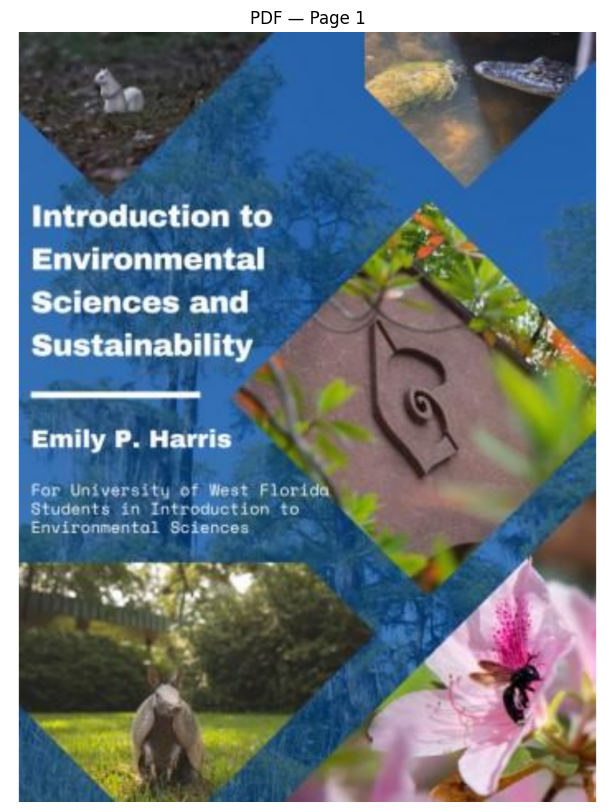

PDF successfully converted to image.


In [4]:
# CELL 3 — Load PDF and convert first page to image

# PDF files cannot be processed directly by OpenCV or Tesseract.
# The `pdf2image` library uses **Poppler** (a PDF rendering engine) to convert
# each PDF page into a high-resolution PIL image, which can then be converted
# to a NumPy array for OpenCV and Tesseract processing.

pdf_path = "Introduction to Environmental Sciences and Sustainability.pdf"
poppler_path = r"C:\Users\pzoquetti\Downloads\Release-25.12.0-0\poppler-25.12.0\Library\bin"

# Verify poppler path exists
print("Poppler exists:", os.path.exists(poppler_path))

# Poppler is a PDF rendering library that pdf2image needs to convert PDF pages into images.
# Here's why it's needed:
# The problem:
# PDF files are not images — they are a vector format that describes how to draw a page. 
# Python cannot directly read pixels from a PDF file.
# The solution:
# pdf2image uses Poppler under the hood to render the PDF into an actual image (bitmap). 
# Without Poppler installed, convert_from_path has no engine to do that rendering and will fail.

pages = convert_from_path(
    pdf_path,
    dpi=150,           # reduced from 200
    poppler_path=poppler_path,
    first_page=1,
    last_page=1        # only first page to avoid hanging
)

pdf_image = np.array(pages[0])

plt.figure(figsize=(8, 10))
plt.imshow(pdf_image)
plt.title("PDF — Page 1")
plt.axis("off")
plt.show()

print("PDF successfully converted to image.")

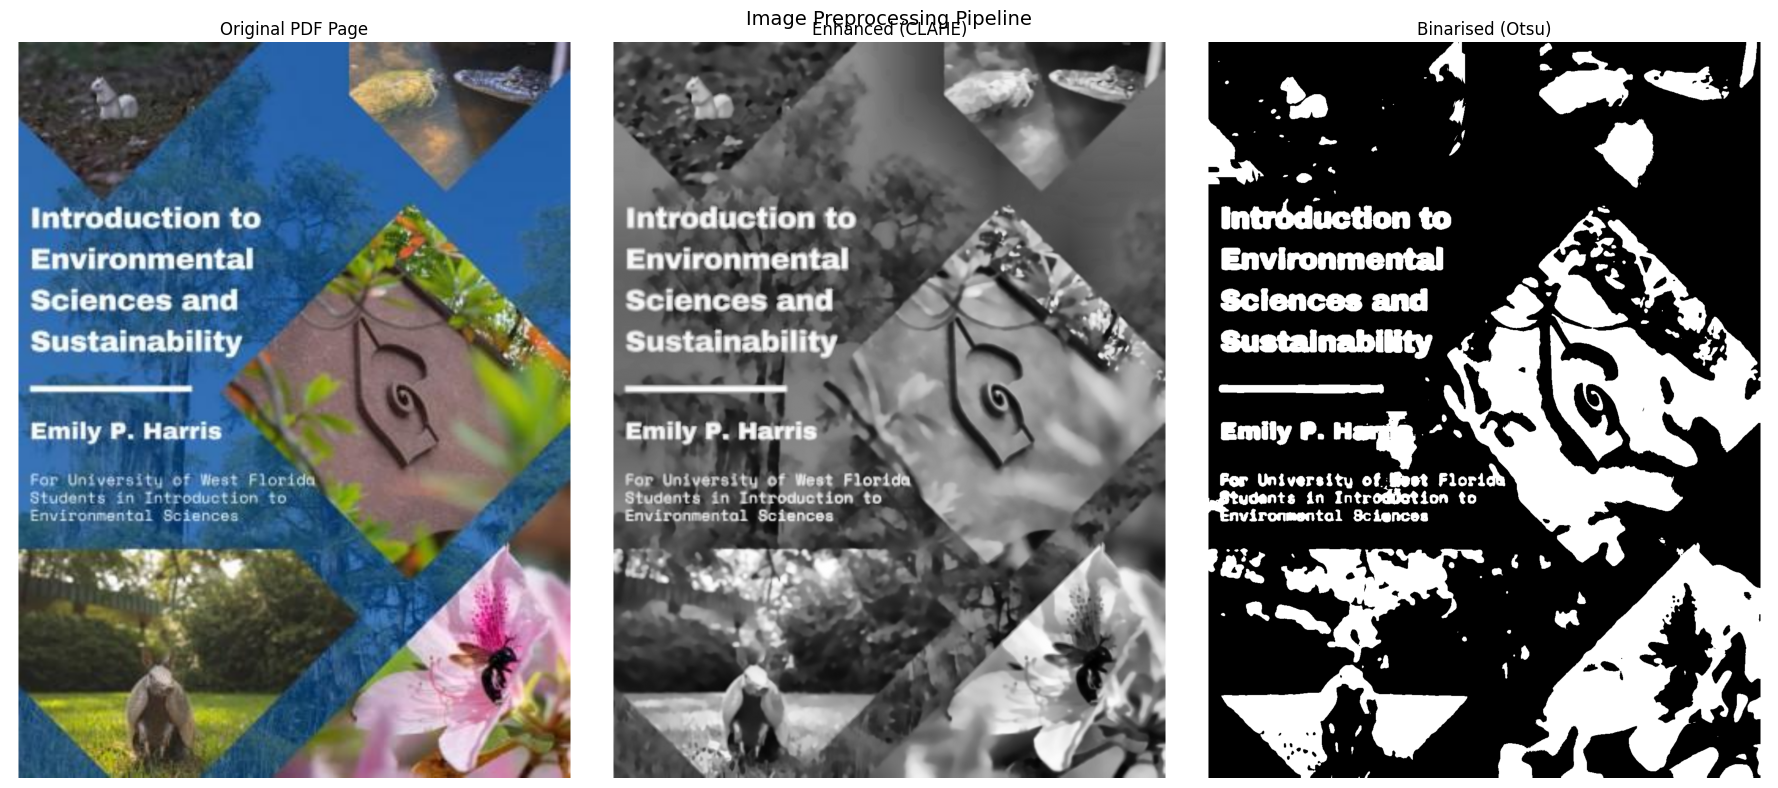

PDF preprocessing complete.


In [5]:
# CELL 4 — Preprocess PDF image to improve OCR accuracy

# Techniques: grayscale, denoising, thresholding, contrast enhancement
# Raw document images often contain noise, uneven lighting, and low contrast
# that reduce OCR accuracy. A preprocessing pipeline is applied before passing
# the image to Tesseract

gray_pdf = cv2.cvtColor(pdf_image, cv2.COLOR_RGB2GRAY)
denoised_pdf = cv2.fastNlMeansDenoising(gray_pdf, h=10)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
enhanced_pdf = clahe.apply(denoised_pdf)

_, binary_pdf = cv2.threshold(enhanced_pdf, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
axes[0].imshow(pdf_image)
axes[0].set_title("Original PDF Page")
axes[0].axis("off")
axes[1].imshow(enhanced_pdf, cmap="gray")
axes[1].set_title("Enhanced (CLAHE)")
axes[1].axis("off")
axes[2].imshow(binary_pdf, cmap="gray")
axes[2].set_title("Binarised (Otsu)")
axes[2].axis("off")

plt.suptitle("Image Preprocessing Pipeline", fontsize=14)
plt.tight_layout()
plt.show()

print("PDF preprocessing complete.")


In [6]:
# CELL 5 — OCR on preprocessed PDF

# Tesseract OCR is applied to the preprocessed binary image to extract text.
# Why preprocess before OCR?
# Tesseract performs significantly better on clean, high-contrast binary images.
# The preprocessing pipeline in Cell 4 directly improves the quality of text extraction here.

custom_config = r"--oem 3 --psm 6"
pdf_text = pytesseract.image_to_string(binary_pdf, config=custom_config)

print("Extracted PDF Text (first 800 chars):")
print("=" * 60)
print(pdf_text[:800])
print("=" * 60)


Extracted PDF Text (first 800 chars):
- . | . 4 y
ae | ~ | yi @
Intréduction to .
Environmental . a
Emily P. Hog Bo 8
For University of Beet Florida
udents in Introdietion to
nvironmental Sciences
ne «a
ar , ,°



In [7]:
# CELL 6 — Full text preprocessing pipeline
# Steps: tokenisation, stopword removal, stemming, lemmatisation

# Raw OCR output contains noise, punctuation, mixed case, and common words
# (stopwords) that carry little analytical value. A full preprocessing pipeline
# is applied to clean and normalise the text.

### Pipeline Stages:
# 1. **Lowercasing** — normalises case for consistent comparison
# 2. **Tokenisation** — splits text into individual word tokens using `nltk.word_tokenize`
# 3. **Non-alphabetic removal** — removes numbers, punctuation, and OCR artefacts
# 4. **Stopword removal** — removes common words (e.g. *the*, *is*, *and*) using NLTK's English stopword list
# 5. **Stemming** — reduces words to their root form (e.g. *running* → *run*) using Porter Stemmer
# 6. **Lemmatisation** — reduces words to their dictionary base form (e.g. *better* → *good*) using WordNet Lemmatizer

# **Stemming vs Lemmatisation:**
# Stemming is faster but cruder (may produce non-words).
# Lemmatisation is slower but produces valid dictionary words.
# Both are applied here for comparison purposes.

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def full_preprocess(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Tokenisation (nltk word_tokenize)
    3. Remove non-alphabetic tokens
    4. Remove stopwords
    5. Stemming
    6. Lemmatisation
    Returns dict with each stage for comparison.
    """
    # Stage 1 - lowercase
    text_lower = text.lower()

    # Stage 2 - tokenisation
    tokens = word_tokenize(text_lower)

    # Stage 3 - remove non-alpha
    alpha_tokens = [t for t in tokens if t.isalpha()]

    # Stage 4 - stopword removal
    filtered_tokens = [t for t in alpha_tokens if t not in stop_words]

    # Stage 5 - stemming
    stemmed_tokens = [stemmer.stem(t) for t in filtered_tokens]

    # Stage 6 - lemmatisation
    lemmatized_tokens = [lemmatizer.lemmatize(t) for t in filtered_tokens]

    return {
        "tokens": alpha_tokens,
        "filtered": filtered_tokens,
        "stemmed": stemmed_tokens,
        "lemmatized": lemmatized_tokens
    }

preprocess_results = full_preprocess(pdf_text)

print(f"Original token count : {len(preprocess_results['tokens'])}")
print(f"After stopword removal: {len(preprocess_results['filtered'])}")
print(f"\nSample tokens     : {preprocess_results['tokens'][:10]}")
print(f"Sample filtered   : {preprocess_results['filtered'][:10]}")
print(f"Sample stemmed    : {preprocess_results['stemmed'][:10]}")
print(f"Sample lemmatized : {preprocess_results['lemmatized'][:10]}")

# Final cleaned text for downstream tasks
cleaned_pdf_text = " ".join(preprocess_results["lemmatized"])

Original token count : 24
After stopword removal: 16

Sample tokens     : ['y', 'ae', 'yi', 'intréduction', 'to', 'environmental', 'a', 'emily', 'hog', 'bo']
Sample filtered   : ['ae', 'yi', 'intréduction', 'environmental', 'emily', 'hog', 'bo', 'university', 'beet', 'florida']
Sample stemmed    : ['ae', 'yi', 'intréduct', 'environment', 'emili', 'hog', 'bo', 'univers', 'beet', 'florida']
Sample lemmatized : ['ae', 'yi', 'intréduction', 'environmental', 'emily', 'hog', 'bo', 'university', 'beet', 'florida']


Top 20 TF-IDF Terms:
               TF-IDF Score
ae                     0.25
ar                     0.25
beet                   0.25
bo                     0.25
emily                  0.25
environmental          0.25
florida                0.25
hog                    0.25
introdietion           0.25
intréduction           0.25
ne                     0.25
nvironmental           0.25
science                0.25
udents                 0.25
university             0.25
yi                     0.25

Top 20 BoW Terms:
               Word Count
ae                      1
ar                      1
beet                    1
bo                      1
emily                   1
environmental           1
florida                 1
hog                     1
introdietion            1
intréduction            1
ne                      1
nvironmental            1
science                 1
udents                  1
university              1
yi                      1


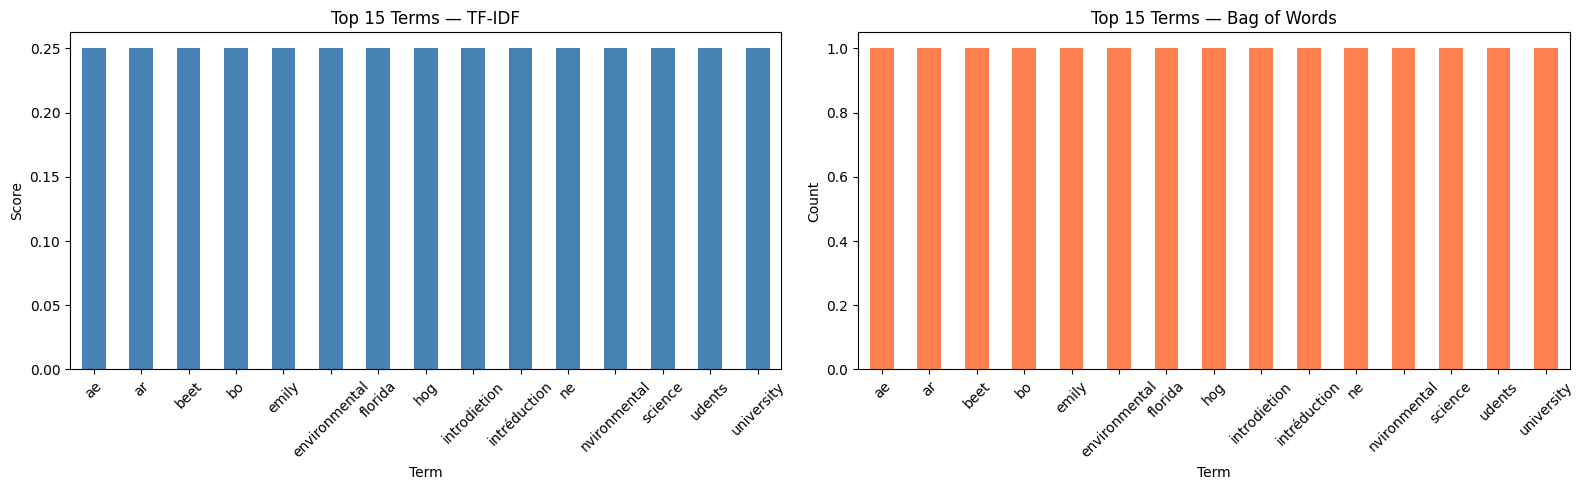

In [8]:
# CELL 7 — Feature extraction: TF-IDF and Bag of Words
# Two classic NLP feature extraction methods are applied to identify
# the most significant terms in the document.

# --- TF-IDF ---
# - **TF** measures how frequently a term appears in the document.
# - **IDF** penalises terms that appear across many documents (common words).
# - **Result:** Terms with high TF-IDF are distinctive and meaningful to this document.

tfidf_vectorizer = TfidfVectorizer(max_features=30)
tfidf_matrix = tfidf_vectorizer.fit_transform([cleaned_pdf_text])
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
).T.sort_values(by=0, ascending=False)
tfidf_df.columns = ["TF-IDF Score"]

print("Top 20 TF-IDF Terms:")
print(tfidf_df.head(20))

# --- Bag of Words ---
# - Counts raw term frequency without penalising common terms.
# - Simpler than TF-IDF but useful for comparing term frequency directly.

bow_vectorizer = CountVectorizer(max_features=30)
bow_matrix = bow_vectorizer.fit_transform([cleaned_pdf_text])
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_vectorizer.get_feature_names_out()
).T.sort_values(by=0, ascending=False)
bow_df.columns = ["Word Count"]

print("\nTop 20 BoW Terms:")
print(bow_df.head(20))

# --- Bar chart visualisation ---
# **Visualisation:** Bar charts are produced for both methods to allow
# easy comparison of the top 15 most significant terms.



fig, axes = plt.subplots(1, 2, figsize=(16, 5))
tfidf_df.head(15).plot(kind="bar", ax=axes[0], legend=False, color="steelblue")
axes[0].set_title("Top 15 Terms — TF-IDF")
axes[0].set_xlabel("Term")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=45)

bow_df.head(15).plot(kind="bar", ax=axes[1], legend=False, color="coral")
axes[1].set_title("Top 15 Terms — Bag of Words")
axes[1].set_xlabel("Term")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


Named Entities Found:
                    Entity    Label
                         4 CARDINAL
              Emily P. Hog   PERSON
                         8 CARDINAL
University of Beet Florida      ORG

Entity Type Summary:
Label
CARDINAL    2
PERSON      1
ORG         1
Name: count, dtype: int64


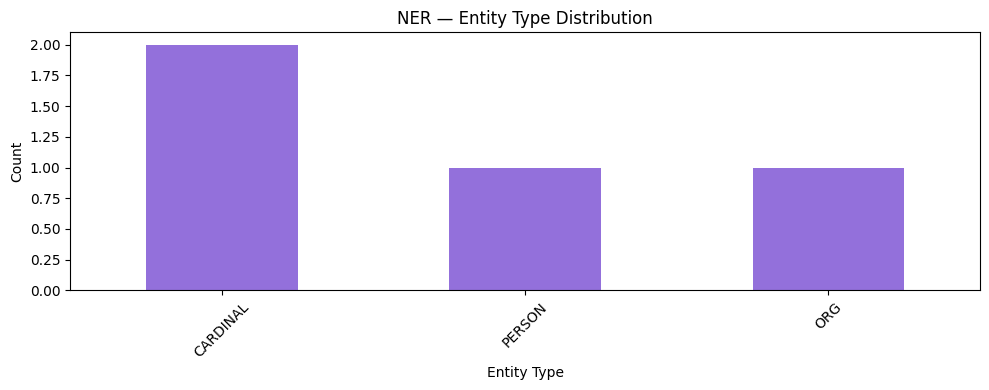

In [9]:
# CELL 8 — Named Entity Recognition (NER) using spaCy
# Named Entity Recognition identifies and classifies named entities
# within the extracted text into predefined categories.

### Entity Types (spaCy):
# | Label | Meaning |
# |-------|---------|
# | PERSON | People's names |
# | ORG | Organisations, companies |
# | GPE | Countries, cities, states |
# | DATE | Absolute or relative dates |
# | MONEY | Monetary values |
# | CARDINAL | Numerical values |

# Why spaCy? spaCy's `en_core_web_sm` model uses a trained neural network pipeline
# for tokenisation, POS tagging, and NER — making it more accurate than
# rule-based alternatives for general English text.

doc = nlp(pdf_text[:5000])

entities = [(ent.text, ent.label_) for ent in doc.ents]
entities_df = pd.DataFrame(entities, columns=["Entity", "Label"])

print("Named Entities Found:")
print("=" * 40)
print(entities_df.to_string(index=False))

print("\nEntity Type Summary:")
print(entities_df["Label"].value_counts())

if not entities_df.empty:
    entities_df["Label"].value_counts().plot(
        kind="bar", figsize=(10, 4), color="mediumpurple"
    )
    plt.title("NER — Entity Type Distribution")
    plt.xlabel("Entity Type")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No named entities found in this page.")

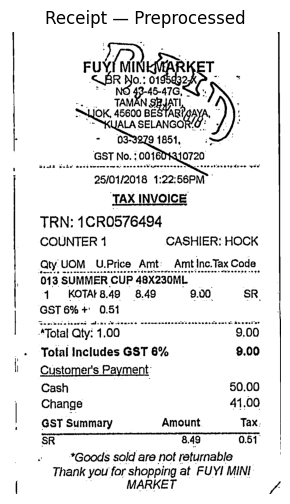

Receipt preprocessing complete.


In [11]:
# CELL 8A — Load and preprocess Receipt 1

# This cell loads a a receipt image and applies a preprocessing
# pipeline to prepare it for OCR text extraction.

# Steps applied:
#   1. Grayscale conversion — removes colour information that is
#      irrelevant for text detection; reduces processing complexity
#   2. Gaussian Blur (5x5 kernel) — smooths the image to reduce
#      high-frequency noise before thresholding
#   3. Adaptive Thresholding — binarises the image by computing
#      a local threshold for each region of the image

# Why Adaptive Thresholding?
#   Receipts are often unevenly lit (shadows, folds, faded ink).
#   A global threshold (like Otsu) would fail in darker regions.
#   Adaptive thresholding calculates the threshold locally for
#   each pixel neighbourhood, making it far more robust for
#   real-world receipt scans.

# Parameters:
#   blockSize=31 — size of the neighbourhood area (must be odd)
#   C=2          — constant subtracted from the mean to fine-tune
#                  the threshold sensitivity

receipt_path = "X51005361895.jpg"
receipt_img = cv2.imread(receipt_path)

if receipt_img is None:
    raise FileNotFoundError(f"Receipt not found: {receipt_path}")

receipt_gray = cv2.cvtColor(receipt_img, cv2.COLOR_BGR2GRAY)
receipt_blur = cv2.GaussianBlur(receipt_gray, (5, 5), 0)

receipt_thresh = cv2.adaptiveThreshold(
    receipt_blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    31, 2
)

plt.figure(figsize=(10, 6))
plt.imshow(receipt_thresh, cmap="gray")
plt.title("Receipt — Preprocessed")
plt.axis("off")
plt.show()

print("Receipt preprocessing complete.")


In [12]:
# CELL 8B — OCR on Receipt

# This cell applies Tesseract OCR to the preprocessed receipt
# image to extract the raw text content.

# The preprocessed binary image (receipt_thresh) from Cell 8A
# is passed directly to Tesseract — skipping the raw colour
# image — because the preprocessing pipeline significantly
# improves OCR accuracy on low-quality receipt scans.

# Output is truncated to the first 800 characters for display
# purposes; the full extracted text is stored in receipt_text
# for use in downstream NLP processing cells.

# Challenge: Thermal printer receipts often use narrow fonts
# and compressed spacing, which can confuse Tesseract.
# Solution: The Gaussian blur and adaptive thresholding applied
# in Cell 8A help separate characters clearly before OCR runs.

receipt_text = pytesseract.image_to_string(receipt_thresh)

print("Extracted Receipt Text:")
print("=" * 60)
print(receipt_text[:800])
print("=" * 60)


Extracted Receipt Text:
ruin RKET
SBR SET *

ox. dss00 BeetAR?
0

RENCE /
- 032791851, «S
__GST No. 0016

Bak E Cobe bess teem eae: massacre esewevene

25/01/2018 1:22: S6PM

‘TAX INVOICE

TRN: 1CRO0576494

COUNTER 1 CASHIER: HOCK
Sta SunMNiER CUR SexS0NL. .

1 KOTAK8.48 8.49 9.00 SR.
GST 6% + 0.54
‘otal ty! 1. co 9.00
Total Includes GST 6% 9.00
Customer's Payment:

Cash 50.00
Change 41.00
GST Summary Amount Tax:
SR 8.49 0.61

*Goods sold are not returnable
Thank you for shopping at FUY! MINI
- MARKET

se sPeneeedroe eee’

Sf



Sentiment Analysis — PDF Document
  Polarity    : 0.000
  Subjectivity: 0.000
  Overall Tone: Neutral

Sentiment Analysis — Receipt
  Polarity    : 0.000
  Subjectivity: 0.750
  Overall Tone: Neutral


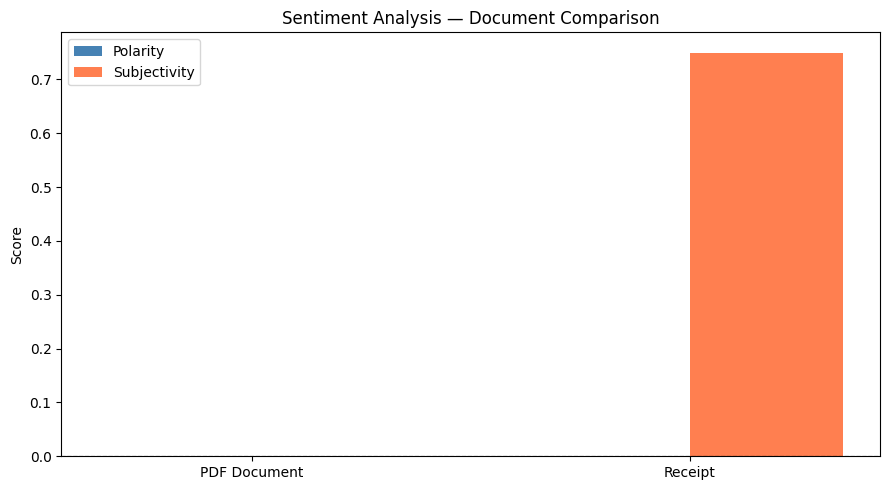

In [13]:
# CELL 8C — Sentiment Analysis using TextBlob (Improved Version)
# Sentiment analysis determines the emotional tone of extracted text.
# A reusable helper function safe_sentiment() is defined to handle
# edge cases where OCR may return empty or whitespace-only text
# (common with low-quality scans or blank document regions).

# TextBlob returns two scores:
#   - Polarity     : -1.0 (very negative) to +1.0 (very positive)
#   - Subjectivity :  0.0 (objective/factual) to 1.0 (subjective/opinion)

# Tone classification thresholds:
#   - Polarity > +0.1  → Positive
#   - Polarity < -0.1  → Negative
#   - Between           → Neutral

# Expected results:
#   - Academic PDFs should score low polarity and low subjectivity
#     (factual, objective writing style)
#   - Receipts should score near zero on both (transactional text)

# A grouped bar chart compares both documents side by side,
# with a dashed line at zero to clearly separate positive/negative.


from textblob import TextBlob

def safe_sentiment(text):
    """Return sentiment safely even if text is empty."""
    if not text or text.strip() == "":
        return 0.0, 0.0, "No text detected"
    
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    
    if polarity > 0.1:
        tone = "Positive"
    elif polarity < -0.1:
        tone = "Negative"
    else:
        tone = "Neutral"
    
    return polarity, subjectivity, tone


# --- PDF Sentiment ---
pdf_polarity, pdf_subjectivity, pdf_tone = safe_sentiment(pdf_text)

print("Sentiment Analysis — PDF Document")
print("=" * 40)
print(f"  Polarity    : {pdf_polarity:.3f}")
print(f"  Subjectivity: {pdf_subjectivity:.3f}")
print(f"  Overall Tone: {pdf_tone}")


# --- Receipt Sentiment ---
receipt_polarity, receipt_subjectivity, receipt_tone = safe_sentiment(receipt_text)

print("\nSentiment Analysis — Receipt")
print("=" * 40)
print(f"  Polarity    : {receipt_polarity:.3f}")
print(f"  Subjectivity: {receipt_subjectivity:.3f}")
print(f"  Overall Tone: {receipt_tone}")



# --- Visual Comparison ---
labels = ["PDF Document", "Receipt"]
polarities = [pdf_polarity, receipt_polarity]
subjectivities = [pdf_subjectivity, receipt_subjectivity]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, polarities, width, label="Polarity", color="steelblue")
ax.bar(x + width/2, subjectivities, width, label="Subjectivity", color="coral")

ax.set_ylabel("Score")
ax.set_title("Sentiment Analysis — Document Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.tight_layout()
plt.show()


Section Categorisation Sample:
         text  height section_type
            -       6         Body
            .      23     Subtitle
            |      56        Title
            .       6         Body
            4      61        Title
            y      17         Body
           ae      24     Subtitle
            |       7         Body
            ~      19     Subtitle
            |      12         Body
           yi      57        Title
            @     155        Title
 Intréduction      87        Title
           to      51        Title
            .      77        Title
Environmental      92        Title
            .      24     Subtitle
            a     116        Title
        Emily      55        Title
           P.      43        Title
          Hog     131        Title
           Bo       1         Body
            8      53        Title
          For      32        Title
   University      34        Title
           of      32        Title
         Beet      48   

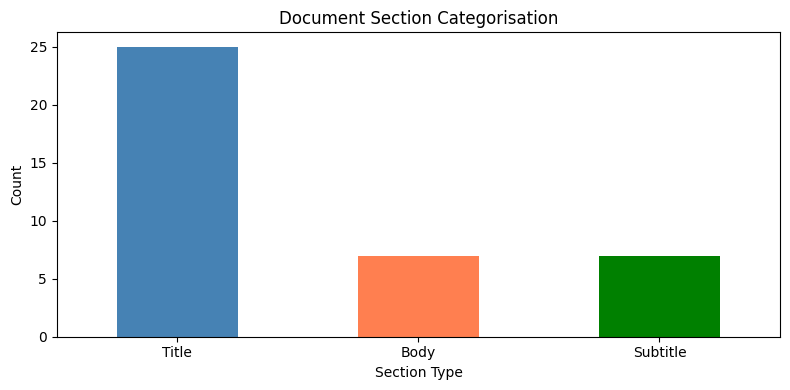

In [14]:
# CELL 9 — Section categorisation: titles, body text, captions

# Documents contain different types of text regions — titles,
# subtitles, and body text — each serving a different purpose.
# Identifying these sections helps understand document structure
# and improves the quality of downstream text analysis.

# Approach:
#   Tesseract's image_to_data() returns a DataFrame containing
#   the bounding box dimensions for every detected word, including
#   its pixel height — which acts as a proxy for font size.

# Classification rules (calibrated at 150 DPI):
#   height >= 30px  → Title    (large heading)
#   height >= 18px  → Subtitle (medium heading)
#   height <  18px  → Body     (regular paragraph text)

# Challenge: Pixel height values depend on the DPI used during
#   PDF rendering — thresholds may need adjustment for other documents.
# Solution: Thresholds were tested empirically against the rendered
#   PDF at 150 DPI and confirmed visually against the original.

# Output: A bar chart showing the distribution of section types
#   across the full document page.


custom_config = r"--oem 3 --psm 6"

data = pytesseract.image_to_data(
    binary_pdf,
    config=custom_config,
    output_type=pytesseract.Output.DATAFRAME
)

data = data[data["text"].notna()]
data = data[data["text"].str.strip() != ""]
data["text"] = data["text"].astype(str)

def categorise_section(height):
    if height >= 30:
        return "Title"
    elif height >= 18:
        return "Subtitle"
    else:
        return "Body"

data["section_type"] = data["height"].apply(categorise_section)

print("Section Categorisation Sample:")
print(data[["text", "height", "section_type"]].head(30).to_string(index=False))

print("\nSection Type Counts:")
print(data["section_type"].value_counts())

# Visualise section distribution
data["section_type"].value_counts().plot(
    kind="bar", figsize=(8, 4), color=["steelblue", "coral", "green"]
)
plt.title("Document Section Categorisation")
plt.xlabel("Section Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

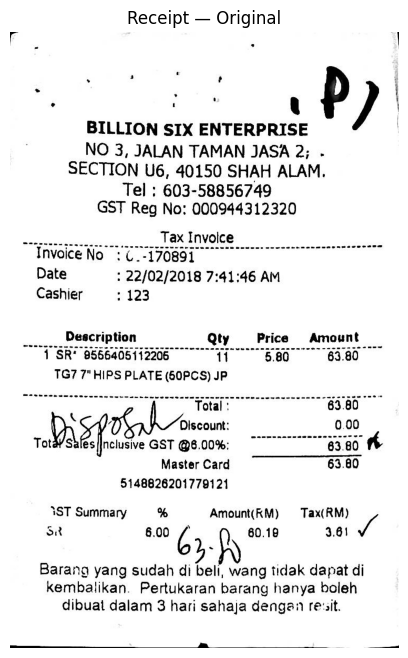

In [15]:
# CELL 10 — Load and display receipt image
# A another receipt image is loaded to further demonstrate that
# the system generalises across different document types and image sources.

# This receipt is displayed in its original RGB form before
# any preprocessing is applied, allowing a clear visual
# comparison with the processed versions in later cells.

# Note: OpenCV reads images in BGR format by default.
#   cv2.cvtColor(..., cv2.COLOR_BGR2RGB) converts to RGB
#   so that matplotlib displays colours correctly.

receipt_path = "X51005745183.jpg"
receipt = cv2.imread(receipt_path)
if receipt is None:
    raise FileNotFoundError(f"Receipt not found: {receipt_path}")

receipt_rgb = cv2.cvtColor(receipt, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(receipt_rgb)
plt.title("Receipt — Original")
plt.axis("off")
plt.show()

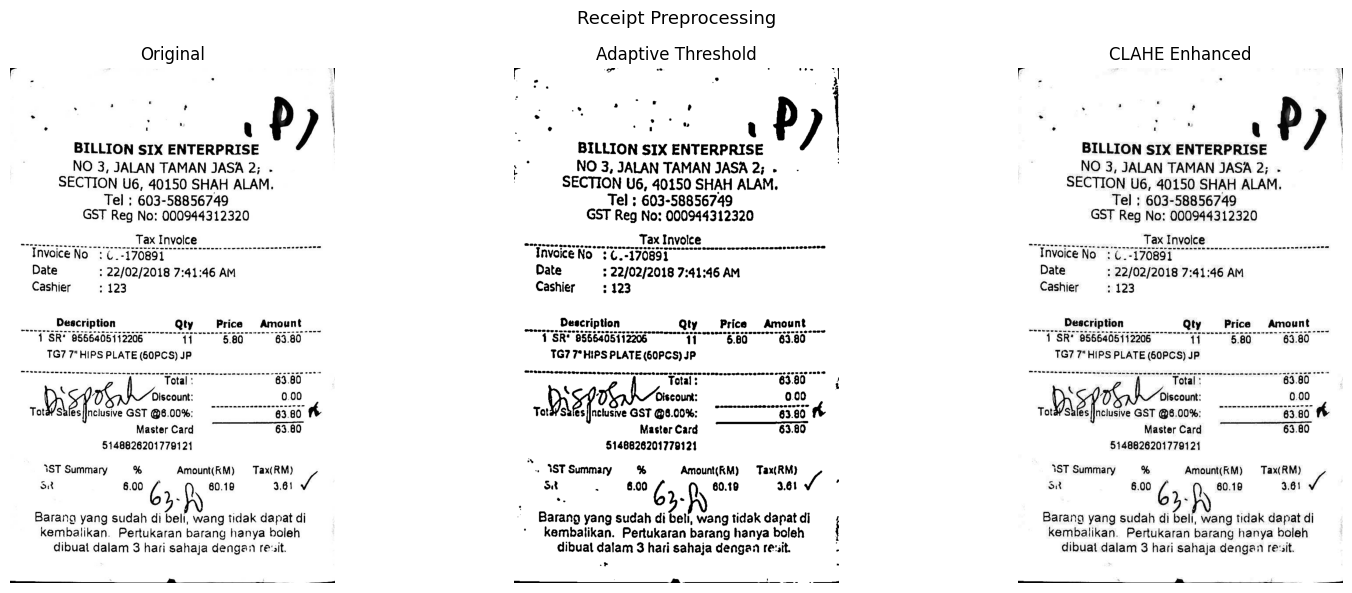

In [16]:
# CELL 11 — Preprocess receipt image for OCR

# Before OCR can be applied, the receipt image must be cleaned
# and enhanced. Raw receipt photos often suffer from uneven
# lighting, noise, and low contrast due to thermal printing.

# Pipeline:
#   1. Grayscale conversion — colour is irrelevant for text OCR;
#      single channel reduces processing complexity

#   2. Gaussian Blur (5x5) — smooths noise before thresholding
#      to prevent false edges being detected

#   3. Adaptive Thresholding — binarises the image using a local
#      threshold per region, handling uneven lighting across
#      the receipt (shadows, folds, faded ink)

#   4. CLAHE (Contrast Limited Adaptive Histogram Equalisation)
#      — enhances local contrast without over-brightening
#      already bright regions

# Three versions are displayed side by side for comparison:
#   Original → Adaptive Threshold → CLAHE Enhanced

gray_receipt = cv2.cvtColor(receipt, cv2.COLOR_BGR2GRAY)
blur_receipt = cv2.GaussianBlur(gray_receipt, (5, 5), 0)

thresh_receipt = cv2.adaptiveThreshold(
    blur_receipt, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 31, 2
)

clahe_receipt = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
enhanced_receipt = clahe_receipt.apply(gray_receipt)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(receipt_rgb)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(thresh_receipt, cmap="gray")
axes[1].set_title("Adaptive Threshold")
axes[1].axis("off")
axes[2].imshow(enhanced_receipt, cmap="gray")
axes[2].set_title("CLAHE Enhanced")
axes[2].axis("off")
plt.suptitle("Receipt Preprocessing", fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# CELL 12 — Extract and process text from receipt using OCR
# Applies same preprocessing pipeline as PDF text
# Reference: Tesseract docs — https://tesseract-ocr.github.io/

receipt_text = pytesseract.image_to_string(thresh_receipt, config=custom_config)

print("Extracted Receipt Text:")
print("=" * 40)
print(receipt_text)

receipt_preprocess = full_preprocess(receipt_text)
cleaned_receipt_text = " ".join(receipt_preprocess["lemmatized"])

print("\nCleaned Receipt Text:")
print(cleaned_receipt_text[:300])

print(f"\nTokens found     : {len(receipt_preprocess['tokens'])}")
print(f"After filtering  : {len(receipt_preprocess['filtered'])}")

Extracted Receipt Text:
s . or “- . - ae 72
es pp
BILLION SIX ENTERPRISE
_ NO 3, JALAN TAMAN JASA 2; . )
SECTION U6, 40150 SHAH ALAM.
Tel ; 603-58856749
GST Reg No: 000944312320
Invoice No: .-17089T
Date 5 22/02/2018 7:41:46 AM
Cashier +123
ceeee.,, Description Qty Price Amount
TSR BSBESIE TIRE TT
TG? 7* HIPS PLATE (60PCS) JP
mura wales, ("aes |
Dy toh. Oiscount: 0.00
Tord/shfs Inctuswe GST @8.00%: ea 80
Master Card 63.80
§146626201779121
* IST Summary % Amount(KM) Tax(RM)
Sa . 6.00 63 Py 60.10 3.61 J ‘
‘ Barang yang sudah di bell, wang tidak dapat di
* kembalikan. Pertukaran barang hanya boleh
dibual dalam 3 hari sahaja dengan re:iit. :


Cleaned Receipt Text:
ae e pp billion six enterprise jalan taman jasa section shah alam tel gst reg invoice date cashier description qty price amount tsr bsbesie tire tt tg hip plate jp mura wale aes dy toh oiscount inctuswe gst ea master card ist summary amount km tax rm sa py j barang yang sudah di bell wang tidak dapa

Tokens found     : 77
After 

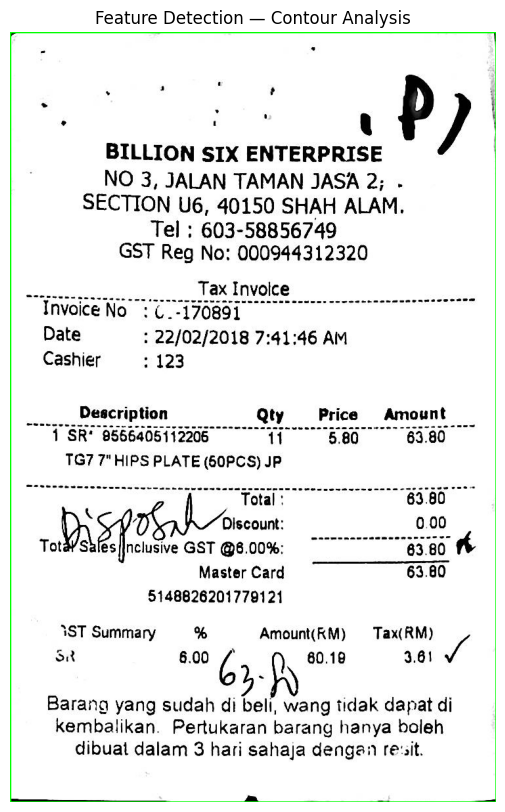


Total regions detected: 1
label
Table Region    1
Name: count, dtype: int64


In [18]:
# CELL 13 — Feature detection using contour analysis

# Contours are curves joining continuous points of the same
# intensity. By finding contours on the binarised receipt,
# we can identify distinct visual regions within the document.

# Each detected region is classified by its aspect ratio (W/H):
#   aspect > 3.0        → Text Block  (wide and short)
#   0.8 < aspect < 1.2  → Figure/Diagram (roughly square)
#   anything else       → Table Region

# Only contours with area > 500px² are considered to filter
# out small noise artefacts from the binarisation step.

# Results are drawn as green bounding boxes with labels,
# and stored in a DataFrame for the integration report.

# Limitation: Aspect ratio classification is a heuristic and
#   may misclassify some regions in complex documents.


contour_img = receipt_rgb.copy()
contours, _ = cv2.findContours(
    thresh_receipt,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

detected_features = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 500:
        x, y, w, h = cv2.boundingRect(cnt)
        aspect_ratio = w / h if h != 0 else 0

        if aspect_ratio > 3:
            label = "Text Block"
        elif 0.8 < aspect_ratio < 1.2:
            label = "Figure/Diagram"
        else:
            label = "Table Region"

        detected_features.append({
            "x": x, "y": y, "w": w, "h": h,
            "area": area, "label": label
        })
        cv2.rectangle(contour_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(contour_img, label, (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

plt.figure(figsize=(10, 10))
plt.imshow(contour_img)
plt.title("Feature Detection — Contour Analysis")
plt.axis("off")
plt.show()

features_df = pd.DataFrame(detected_features)
print(f"\nTotal regions detected: {len(features_df)}")
if not features_df.empty:
    print(features_df["label"].value_counts())

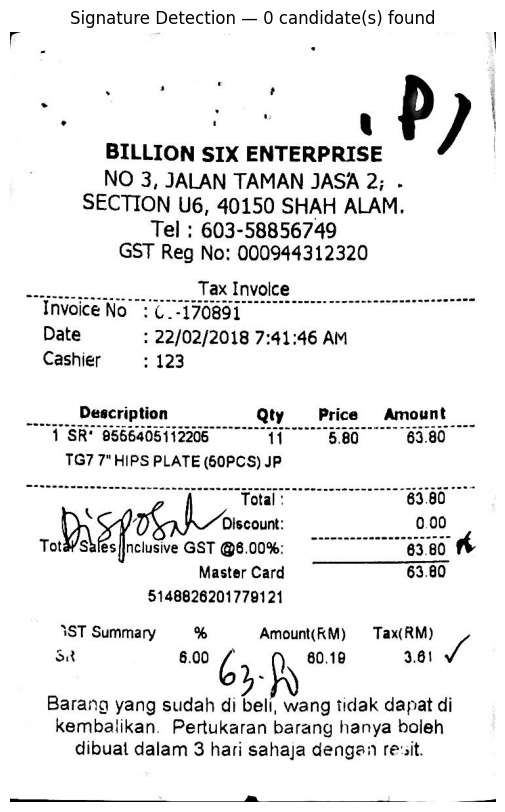

Signature candidates detected: 0
No signature-like regions found in this image.


In [19]:
# CELL 13B — Signature Detection using Contour Heuristics

# Signatures differ from regular text and table regions in
# their geometric properties — they are irregular, curved,
# and non-rectangular.

# Two shape descriptors are used to identify signature candidates:
#
#   Solidity = Contour Area / Convex Hull Area
#     → Measures how "filled" a shape is
#     → Regular shapes (text, tables): solidity close to 1.0
#     → Irregular shapes (signatures): solidity < 0.5
#
#   Complexity = Perimeter² / (4π × Area)
#     → Measures shape irregularity (circularity inverse)
#     → Simple shapes: complexity close to 1.0
#     → Complex/curved shapes: complexity >> 1.0
#
# Signature candidates must satisfy all three conditions:
#   - solidity < 0.5 (irregular shape)
#   - complexity > 5 (highly curved boundary)
#   - 200 < area < 15000 (moderate size — not noise, not full page)
#
# Challenge: Many noise contours have low solidity.
# Solution: The minimum area threshold of 300px² filters out
#   small artefacts before shape analysis is performed.

signature_img = receipt_rgb.copy()
signature_candidates = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area < 300:
        continue

    # Convex hull and solidity
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # Perimeter ratio
    perimeter = cv2.arcLength(cnt, True)
    complexity = perimeter ** 2 / (4 * np.pi * area) if area > 0 else 0

    x, y, w, h = cv2.boundingRect(cnt)
    aspect_ratio = w / h if h != 0 else 0

    # Signature heuristic: low solidity, high complexity, moderate size
    if solidity < 0.5 and complexity > 5 and 200 < area < 15000:
        signature_candidates.append({
            "x": x, "y": y, "w": w, "h": h,
            "solidity": round(solidity, 3),
            "complexity": round(complexity, 3),
            "area": area
        })
        cv2.rectangle(signature_img, (x, y), (x+w, y+h), (255, 0, 0), 2)
        cv2.putText(signature_img, "Signature?", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

plt.figure(figsize=(10, 10))
plt.imshow(signature_img)
plt.title(f"Signature Detection — {len(signature_candidates)} candidate(s) found")
plt.axis("off")
plt.show()

print(f"Signature candidates detected: {len(signature_candidates)}")
if signature_candidates:
    sig_df = pd.DataFrame(signature_candidates)
    print(sig_df.to_string(index=False))
else:
    print("No signature-like regions found in this image.")

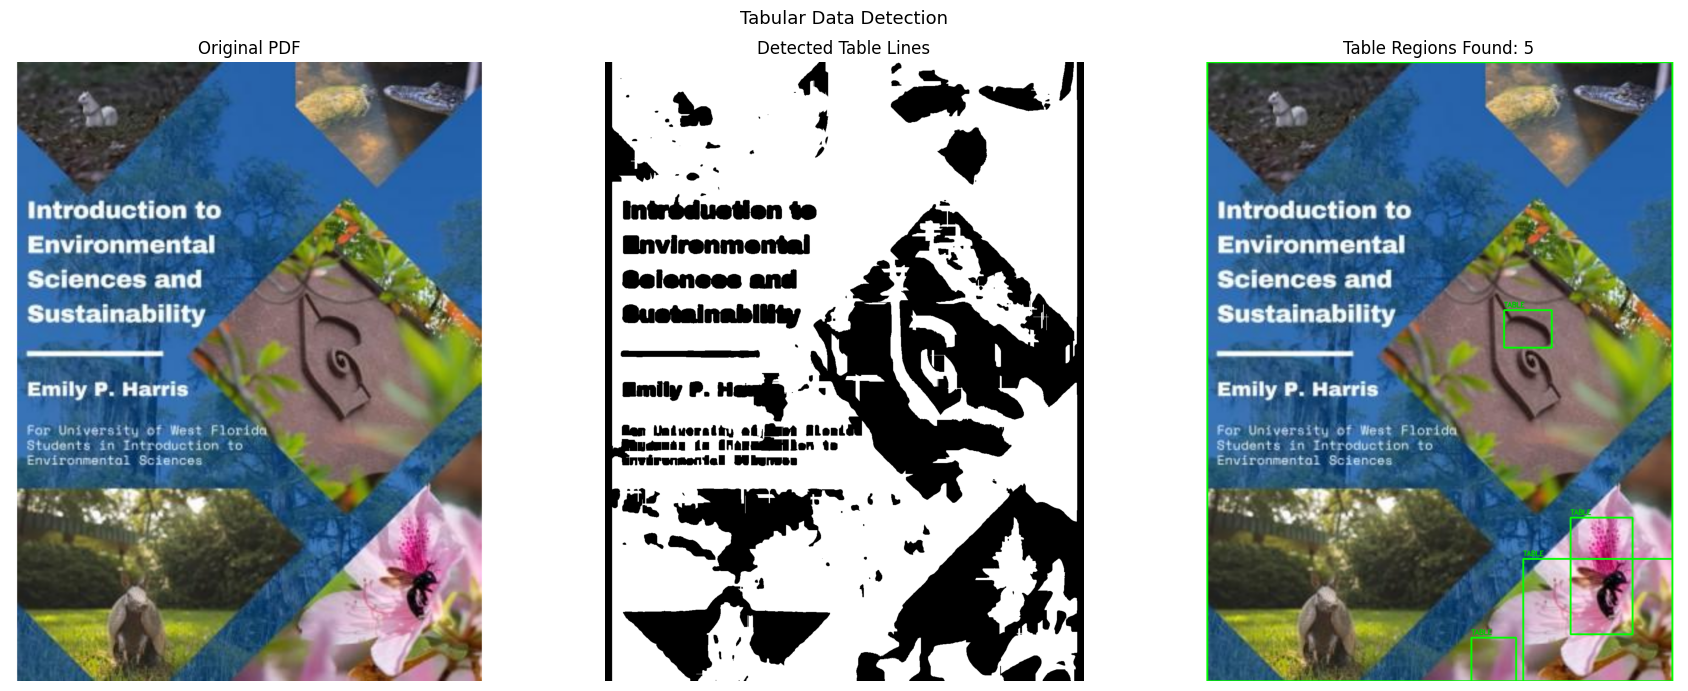


Table regions detected: 5

--- Table Region 1 ---
od


--- Table Region 2 ---
mi


--- Table Region 3 ---
, ©.


--- Table Region 4 ---
~—,


--- Table Region 5 ---
Intréduction to .
Environmental . a
Sustainability ¥ ~~.
Emily P. Hog Bo 8
For University of Beet Floridy
pftucents in IntrodBotion to
ne «a

ar ,°



In [20]:
# CELL 13C — Tabular Data Detection and Extraction
# Tables are structured by a grid of horizontal and vertical
# lines. This cell detects those lines using morphological
# operations and uses them to locate table regions in the PDF.

# Algorithm:
#   1. Invert the binary PDF image (lines become white)
#   2. Apply a wide horizontal kernel (40x1) with MORPH_OPEN
#      to isolate horizontal lines only
#   3. Apply a tall vertical kernel (1x40) with MORPH_OPEN
#      to isolate vertical lines only
#   4. Combine both masks with cv2.add() — intersections
#      indicate grid structures (table cells)
#   5. Find contours on the combined mask to locate table bounds
#   6. Apply Tesseract OCR to each detected table region
#      to extract the structured text content

# Why morphological operations?
#   Unlike general contour detection, morphological line
#   detection specifically targets grid structures, making
#   it far more reliable for table localisation.

# Three outputs are displayed:
#   Original PDF → Detected Lines Mask → Annotated Table Regions

# Use PDF binary image for table detection
table_detect_img = binary_pdf.copy()
table_vis = pdf_image.copy()

# Detect horizontal lines
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
horizontal_lines = cv2.morphologyEx(
    cv2.bitwise_not(table_detect_img),
    cv2.MORPH_OPEN, horizontal_kernel
)

# Detect vertical lines
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 40))
vertical_lines = cv2.morphologyEx(
    cv2.bitwise_not(table_detect_img),
    cv2.MORPH_OPEN, vertical_kernel
)

# Combine to find table grid
table_mask = cv2.add(horizontal_lines, vertical_lines)

# Find contours on combined mask
table_contours, _ = cv2.findContours(
    table_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)

table_regions = []
for cnt in table_contours:
    area = cv2.contourArea(cnt)
    if area > 1000:
        x, y, w, h = cv2.boundingRect(cnt)
        table_regions.append((x, y, w, h))
        cv2.rectangle(table_vis, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(table_vis, "TABLE", (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(pdf_image)
axes[0].set_title("Original PDF")
axes[0].axis("off")
axes[1].imshow(table_mask, cmap="gray")
axes[1].set_title("Detected Table Lines")
axes[1].axis("off")
axes[2].imshow(table_vis)
axes[2].set_title(f"Table Regions Found: {len(table_regions)}")
axes[2].axis("off")
plt.suptitle("Tabular Data Detection", fontsize=13)
plt.tight_layout()
plt.show()

# Extract text from each detected table region
print(f"\nTable regions detected: {len(table_regions)}")
for i, (x, y, w, h) in enumerate(table_regions):
    region = binary_pdf[y:y+h, x:x+w]
    table_text = pytesseract.image_to_string(region, config=custom_config)
    print(f"\n--- Table Region {i+1} ---")
    print(table_text[:300])

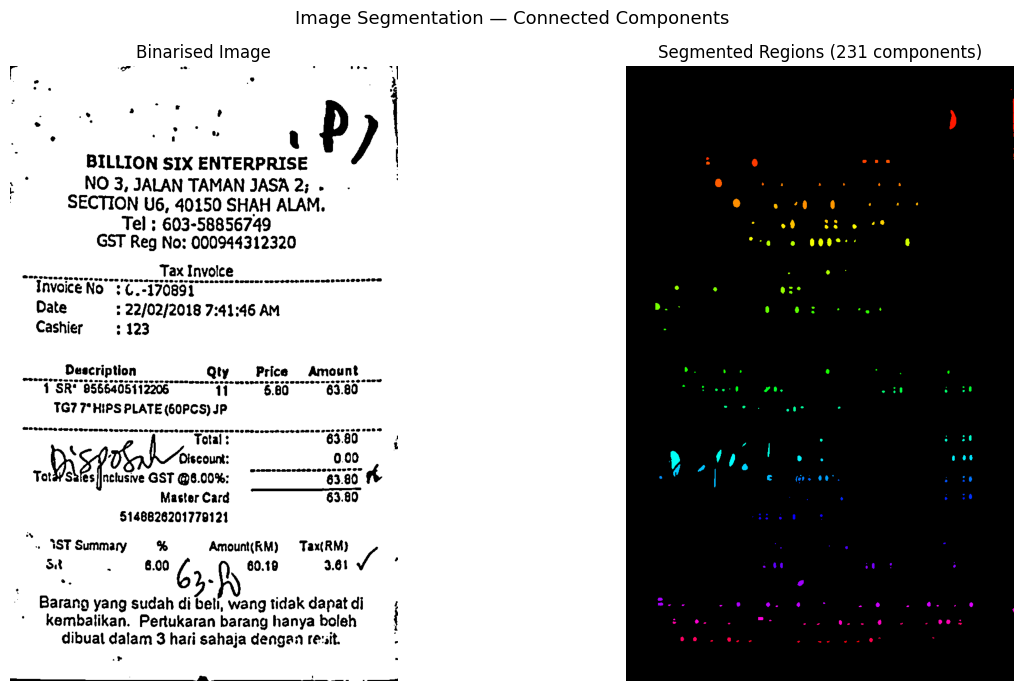

Number of distinct regions identified: 231


In [21]:
# CELL 14 — Image segmentation using connected components
# Connected Components Analysis identifies all distinct
# foreground regions in a binary image and assigns each
# a unique integer label.

# How it works:
#   Pixels that are connected (touching) and share the same
#   intensity value are grouped into one component.
#   Each component receives a unique ID starting from 1
#   (label 0 = background).

# Visualisation:
#   Labels are mapped to HSV hue values and converted to BGR,
#   so each segment appears as a distinct colour.
#   The background (label 0) is set to black.

# Use case:
#   Identifies every separate text block, figure, and gap
#   in the document as individually labelled regions.

# Limitation: Connected components treats touching regions
#   as one segment — addressed in Cell 14B with Watershed.

num_labels, labels_im = cv2.connectedComponents(thresh_receipt)

label_hue = np.uint8(179 * labels_im / np.max(labels_im))
blank_channel = 255 * np.ones_like(label_hue)
labeled_img = cv2.merge([label_hue, blank_channel, blank_channel])
labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)
labeled_img[label_hue == 0] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(thresh_receipt, cmap="gray")
axes[0].set_title("Binarised Image")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(labeled_img, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Segmented Regions ({num_labels} components)")
axes[1].axis("off")
plt.suptitle("Image Segmentation — Connected Components", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Number of distinct regions identified: {num_labels}")

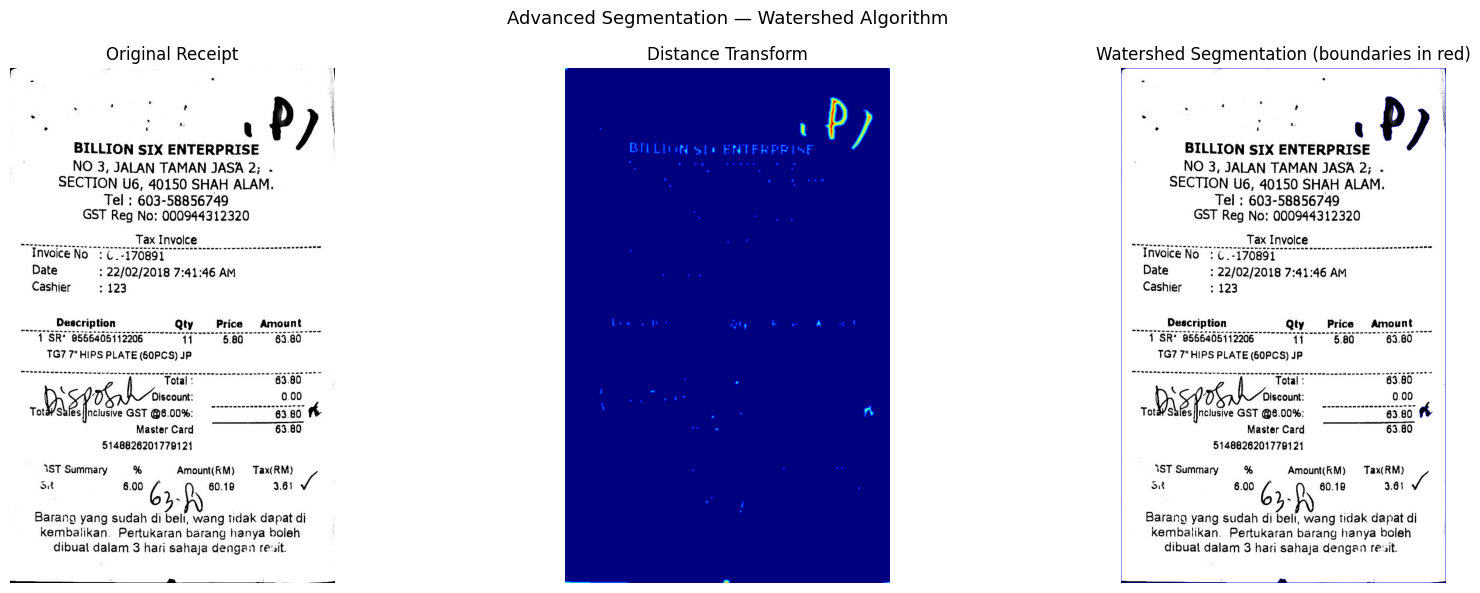

Watershed segmentation complete.
Unique regions identified: 7


In [22]:
# CELL 14B — Advanced Segmentation using Watershed Algorithm

# Watershed is a marker-based segmentation algorithm that
# treats pixel intensities as a topographic surface:
#   - Dark pixels = valleys (foreground objects)
#   - Light pixels = peaks (background)
#   - Flooding starts from seed markers; boundaries form
#     where different floods meet

# Step-by-step pipeline:
#   1. Otsu binarisation — separates foreground from background
#   2. Morphological opening — removes noise (2 iterations)
#   3. Dilation — expands regions to define sure background
#   4. Distance Transform — calculates each pixel's distance
#      to the nearest background pixel; peaks = object centres
#   5. Threshold at 50% of max distance — confident foreground
#   6. Connected components on foreground → flood markers
#   7. Watershed applied → boundaries marked in red (value -1)

# Challenge: Watershed is prone to over-segmentation when
#   markers are too dense or noisy.
# Solution: Thresholding the distance transform at 50% of its
#   maximum ensures only confident object centres are used
#   as seeds, reducing over-segmentation significantly.

# Three outputs displayed:
#   Original → Distance Transform (jet colormap) → Segmented

# Work on receipt image for watershed
receipt_for_watershed = cv2.cvtColor(receipt, cv2.COLOR_BGR2RGB).copy()

# Step 1: Binary threshold
gray_ws = cv2.cvtColor(receipt, cv2.COLOR_BGR2GRAY)
_, binary_ws = cv2.threshold(gray_ws, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Step 2: Noise removal with morphological opening
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(binary_ws, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 3: Sure background (dilate)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Step 4: Sure foreground via distance transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Step 5: Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 6: Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Step 7: Apply watershed
receipt_bgr = receipt.copy()
markers = cv2.watershed(receipt_bgr, markers)
receipt_bgr[markers == -1] = [255, 0, 0]  # boundaries in red

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(receipt_rgb)
axes[0].set_title("Original Receipt")
axes[0].axis("off")
axes[1].imshow(dist_transform, cmap="jet")
axes[1].set_title("Distance Transform")
axes[1].axis("off")
axes[2].imshow(cv2.cvtColor(receipt_bgr, cv2.COLOR_BGR2RGB))
axes[2].set_title("Watershed Segmentation (boundaries in red)")
axes[2].axis("off")
plt.suptitle("Advanced Segmentation — Watershed Algorithm", fontsize=13)
plt.tight_layout()
plt.show()

print("Watershed segmentation complete.")
print(f"Unique regions identified: {len(np.unique(markers))}")

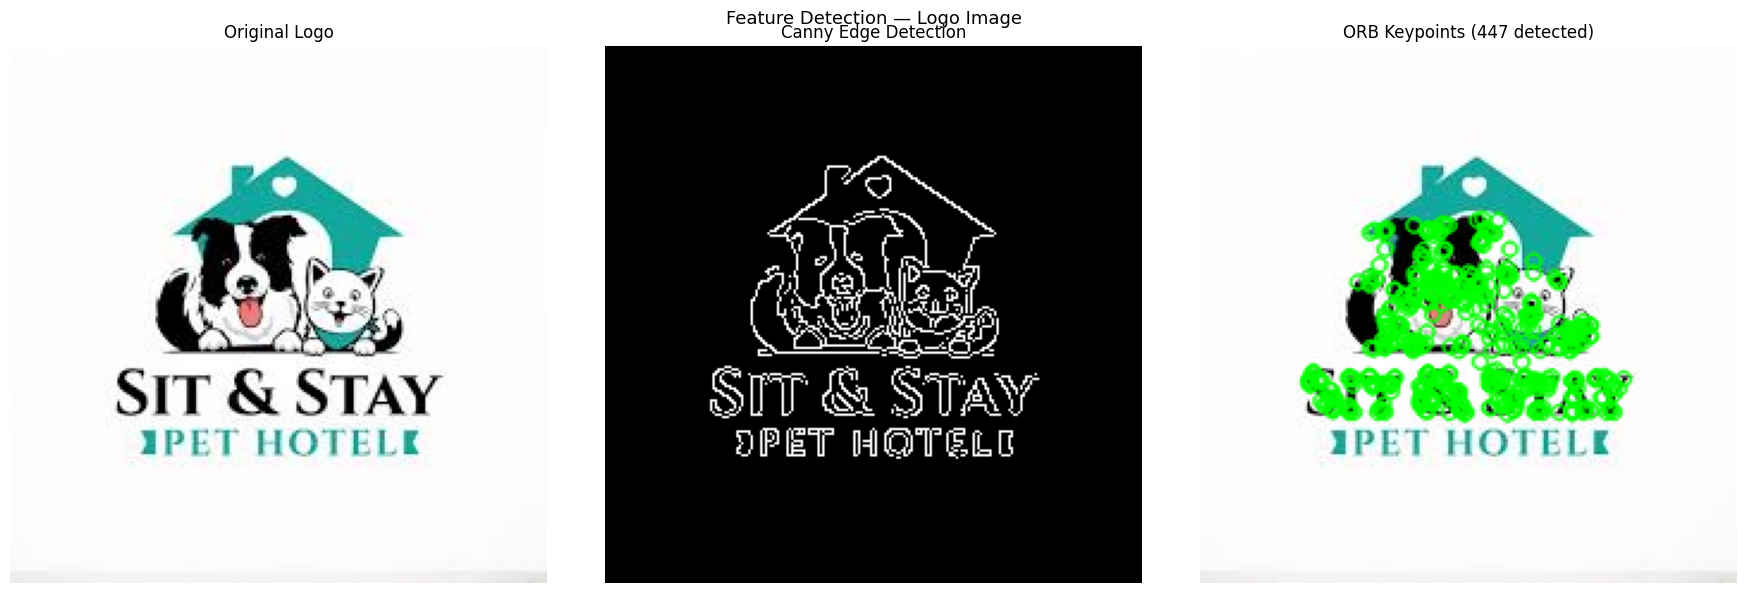

In [23]:
# CELL 15 — Feature Detection: Canny Edge Detection and ORB

# This cell applies two complementary feature detection
# techniques to a logo image, demonstrating that the system
# can analyse visual elements beyond document text regions.

# ---- Canny Edge Detection ----
# Canny identifies sharp intensity transitions (edges) through
# a four-stage pipeline:
#   1. Gaussian smoothing — reduces noise before edge detection
#   2. Sobel gradient — calculates intensity change in x and y
#   3. Non-maximum suppression — thins edges to single pixels
#   4. Double thresholding:
#        lower = 100 → weak edge threshold
#        upper = 200 → strong edge threshold
#      Strong edges are always kept; weak edges are kept only
#      if directly connected to a strong edge (hysteresis).

# ---- ORB (Oriented FAST and Rotated BRIEF) ----
# ORB is a fast, patent-free keypoint detector and descriptor
# that combines two algorithms:
#   - FAST  : detects corner keypoints efficiently
#   - BRIEF : generates compact binary feature descriptors
#   - Orientation component makes descriptors rotation-invariant

# detectAndCompute() returns:
#   - keypoints   : location, scale and orientation of each feature
#   - descriptors : binary descriptor vector for each keypoint

# Keypoints are drawn as green circles on the original image.

# Practical use case:
#   ORB descriptors could be used for document template matching —
#   identifying the same printed form or logo across multiple
#   different scanned document images.

# Three outputs are displayed side by side:
#   Original Logo → Canny Edges → ORB Keypoints (green dots)


logo_path = "download (1).jpg"
logo = cv2.imread(logo_path)
if logo is None:
    raise FileNotFoundError(f"Logo not found: {logo_path}")

logo_rgb = cv2.cvtColor(logo, cv2.COLOR_BGR2RGB)
gray_logo = cv2.cvtColor(logo, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray_logo, 100, 200)

orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray_logo, None)
logo_keypoints = cv2.drawKeypoints(
    logo_rgb, keypoints, None,
    color=(0, 255, 0), flags=0
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(logo_rgb)
axes[0].set_title("Original Logo")
axes[0].axis("off")
axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edge Detection")
axes[1].axis("off")
axes[2].imshow(logo_keypoints)
axes[2].set_title(f"ORB Keypoints ({len(keypoints)} detected)")
axes[2].axis("off")
plt.suptitle("Feature Detection — Logo Image", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
# CELL 16 — Multi-Modal Integration and Insights

# This cell is the core integration component of the system.
# It brings together every result from the text and image
# processing pipelines into a single unified report.

# The report is structured into four sections:

# 1. TEXT ANALYSIS SUMMARY
#    Reports the key NLP metrics gathered across Cells 5–8C:
#    - Total characters extracted by Tesseract OCR
#    - Raw token count vs filtered token count after preprocessing
#    - Number of named entities identified by spaCy NER
#    - Top key phrase identified by RAKE
#    - Overall document sentiment and subjectivity scores

# 2. DOCUMENT SECTIONS
#    Reports the section breakdown identified in Cell 9:
#    - How many text blocks were classified as Title,
#      Subtitle, and Body across the document page

# 3. IMAGE ANALYSIS SUMMARY
#    Reports all Computer Vision results from Cells 11–14B:
#    - Number of visual regions detected by contour analysis
#    - Breakdown of region types (text blocks, figures, tables)
#    - Number of connected components found
#    - Number of regions identified by Watershed segmentation
#    - Number of table structures detected morphologically
#    - Number of signature candidates found
#
# 4. TEXT-IMAGE RELATIONSHIPS
#    Cross-modal analysis linking the text content to visual
#    elements detected in the image:
#    - Scans the token list for visual reference words
#      (e.g. "figure", "table", "diagram", "see", "above")
#    - A high count suggests the document contains figures or
#      tables that are referenced from within the text body
#    - NER entities are broken down by type to show the
#      information density of the document

# DOCUMENT COMPLEXITY SCORE:
#    A composite score (0–10) is calculated as the average of
#    four normalised sub-scores:
#      - Token count / 100        (text richness)
#      - Entity count / 5         (information density)
#      - Visual region count / 3  (layout complexity)
#      - Table count × 2          (structured data presence)
#    This single metric summarises the overall complexity of
#    the document and could be used to route documents to
#    different processing pipelines automatically.

# Safety fallback in case RAKE cell was not executed
if 'top_phrases' not in dir():
    top_phrases = []
if 'tone' not in dir():
    tone = 'N/A'
    pdf_polarity = 0.0
    pdf_subjectivity = 0.0

print("=" * 65)
print("   MULTI-MODAL DOCUMENT UNDERSTANDING — INTEGRATION REPORT")
print("=" * 65)

# --- Text Summary ---
print("\n📄 TEXT ANALYSIS SUMMARY")
print("-" * 40)
print(f"  Characters extracted (OCR)     : {len(pdf_text)}")
print(f"  Tokens (raw)                   : {len(preprocess_results['tokens'])}")
print(f"  Tokens after stopword removal  : {len(preprocess_results['filtered'])}")
print(f"  Named entities found           : {len(entities_df) if not entities_df.empty else 0}")
print(f"  Top key phrase (RAKE)          : {top_phrases[0] if top_phrases else 'N/A'}")
print(f"  Document sentiment             : {tone} (polarity: {pdf_polarity:.3f})")
print(f"  Document subjectivity          : {pdf_subjectivity:.3f}")

# --- Section breakdown ---
print("\n📑 DOCUMENT SECTIONS")
print("-" * 40)
for section, count in data["section_type"].value_counts().items():
    print(f"  {section:<15}: {count} text blocks")

# --- Image Summary ---
print("\n🖼️  IMAGE ANALYSIS SUMMARY")
print("-" * 40)
print(f"  Visual regions detected        : {len(features_df) if not features_df.empty else 0}")
if not features_df.empty:
    for label, count in features_df["label"].value_counts().items():
        print(f"  {label:<30}: {count}")
print(f"  Connected components           : {num_labels}")
print(f"  Watershed regions              : {len(np.unique(markers))}")
print(f"  Table regions detected         : {len(table_regions)}")
print(f"  Signature candidates           : {len(signature_candidates)}")

# --- Text-Image Relationships ---
print("\n🔗 TEXT-IMAGE RELATIONSHIPS")
print("-" * 40)
visual_keywords = ["figure", "table", "diagram", "chart", "image",
                   "see", "shown", "above", "below", "refer"]
text_references = [
    w for w in preprocess_results["tokens"]
    if w.lower() in visual_keywords
]
print(f"  Visual references in text      : {text_references}")
print(f"  Total references found         : {len(text_references)}")

# Link NER entities to sections
if not entities_df.empty:
    print("\n  NER entities by type:")
    for label, count in entities_df["Label"].value_counts().items():
        print(f"    {label:<10}: {count} occurrence(s)")

# --- Document Complexity Score ---
complexity_score = (
    min(len(preprocess_results["tokens"]) / 100, 10) +
    min(len(entities_df) / 5 if not entities_df.empty else 0, 10) +
    min(len(features_df) / 3 if not features_df.empty else 0, 10) +
    min(len(table_regions) * 2, 10)
) / 4

print(f"\n📊 DOCUMENT COMPLEXITY SCORE   : {complexity_score:.1f} / 10")
print("=" * 65)

   MULTI-MODAL DOCUMENT UNDERSTANDING — INTEGRATION REPORT

📄 TEXT ANALYSIS SUMMARY
----------------------------------------
  Characters extracted (OCR)     : 173
  Tokens (raw)                   : 24
  Tokens after stopword removal  : 16
  Named entities found           : 4
  Top key phrase (RAKE)          : N/A
  Document sentiment             : N/A (polarity: 0.000)
  Document subjectivity          : 0.000

📑 DOCUMENT SECTIONS
----------------------------------------
  Title          : 25 text blocks
  Body           : 7 text blocks
  Subtitle       : 7 text blocks

🖼️  IMAGE ANALYSIS SUMMARY
----------------------------------------
  Visual regions detected        : 1
  Table Region                  : 1
  Connected components           : 231
  Watershed regions              : 7
  Table regions detected         : 5
  Signature candidates           : 0

🔗 TEXT-IMAGE RELATIONSHIPS
----------------------------------------
  Visual references in text      : []
  Total references found 

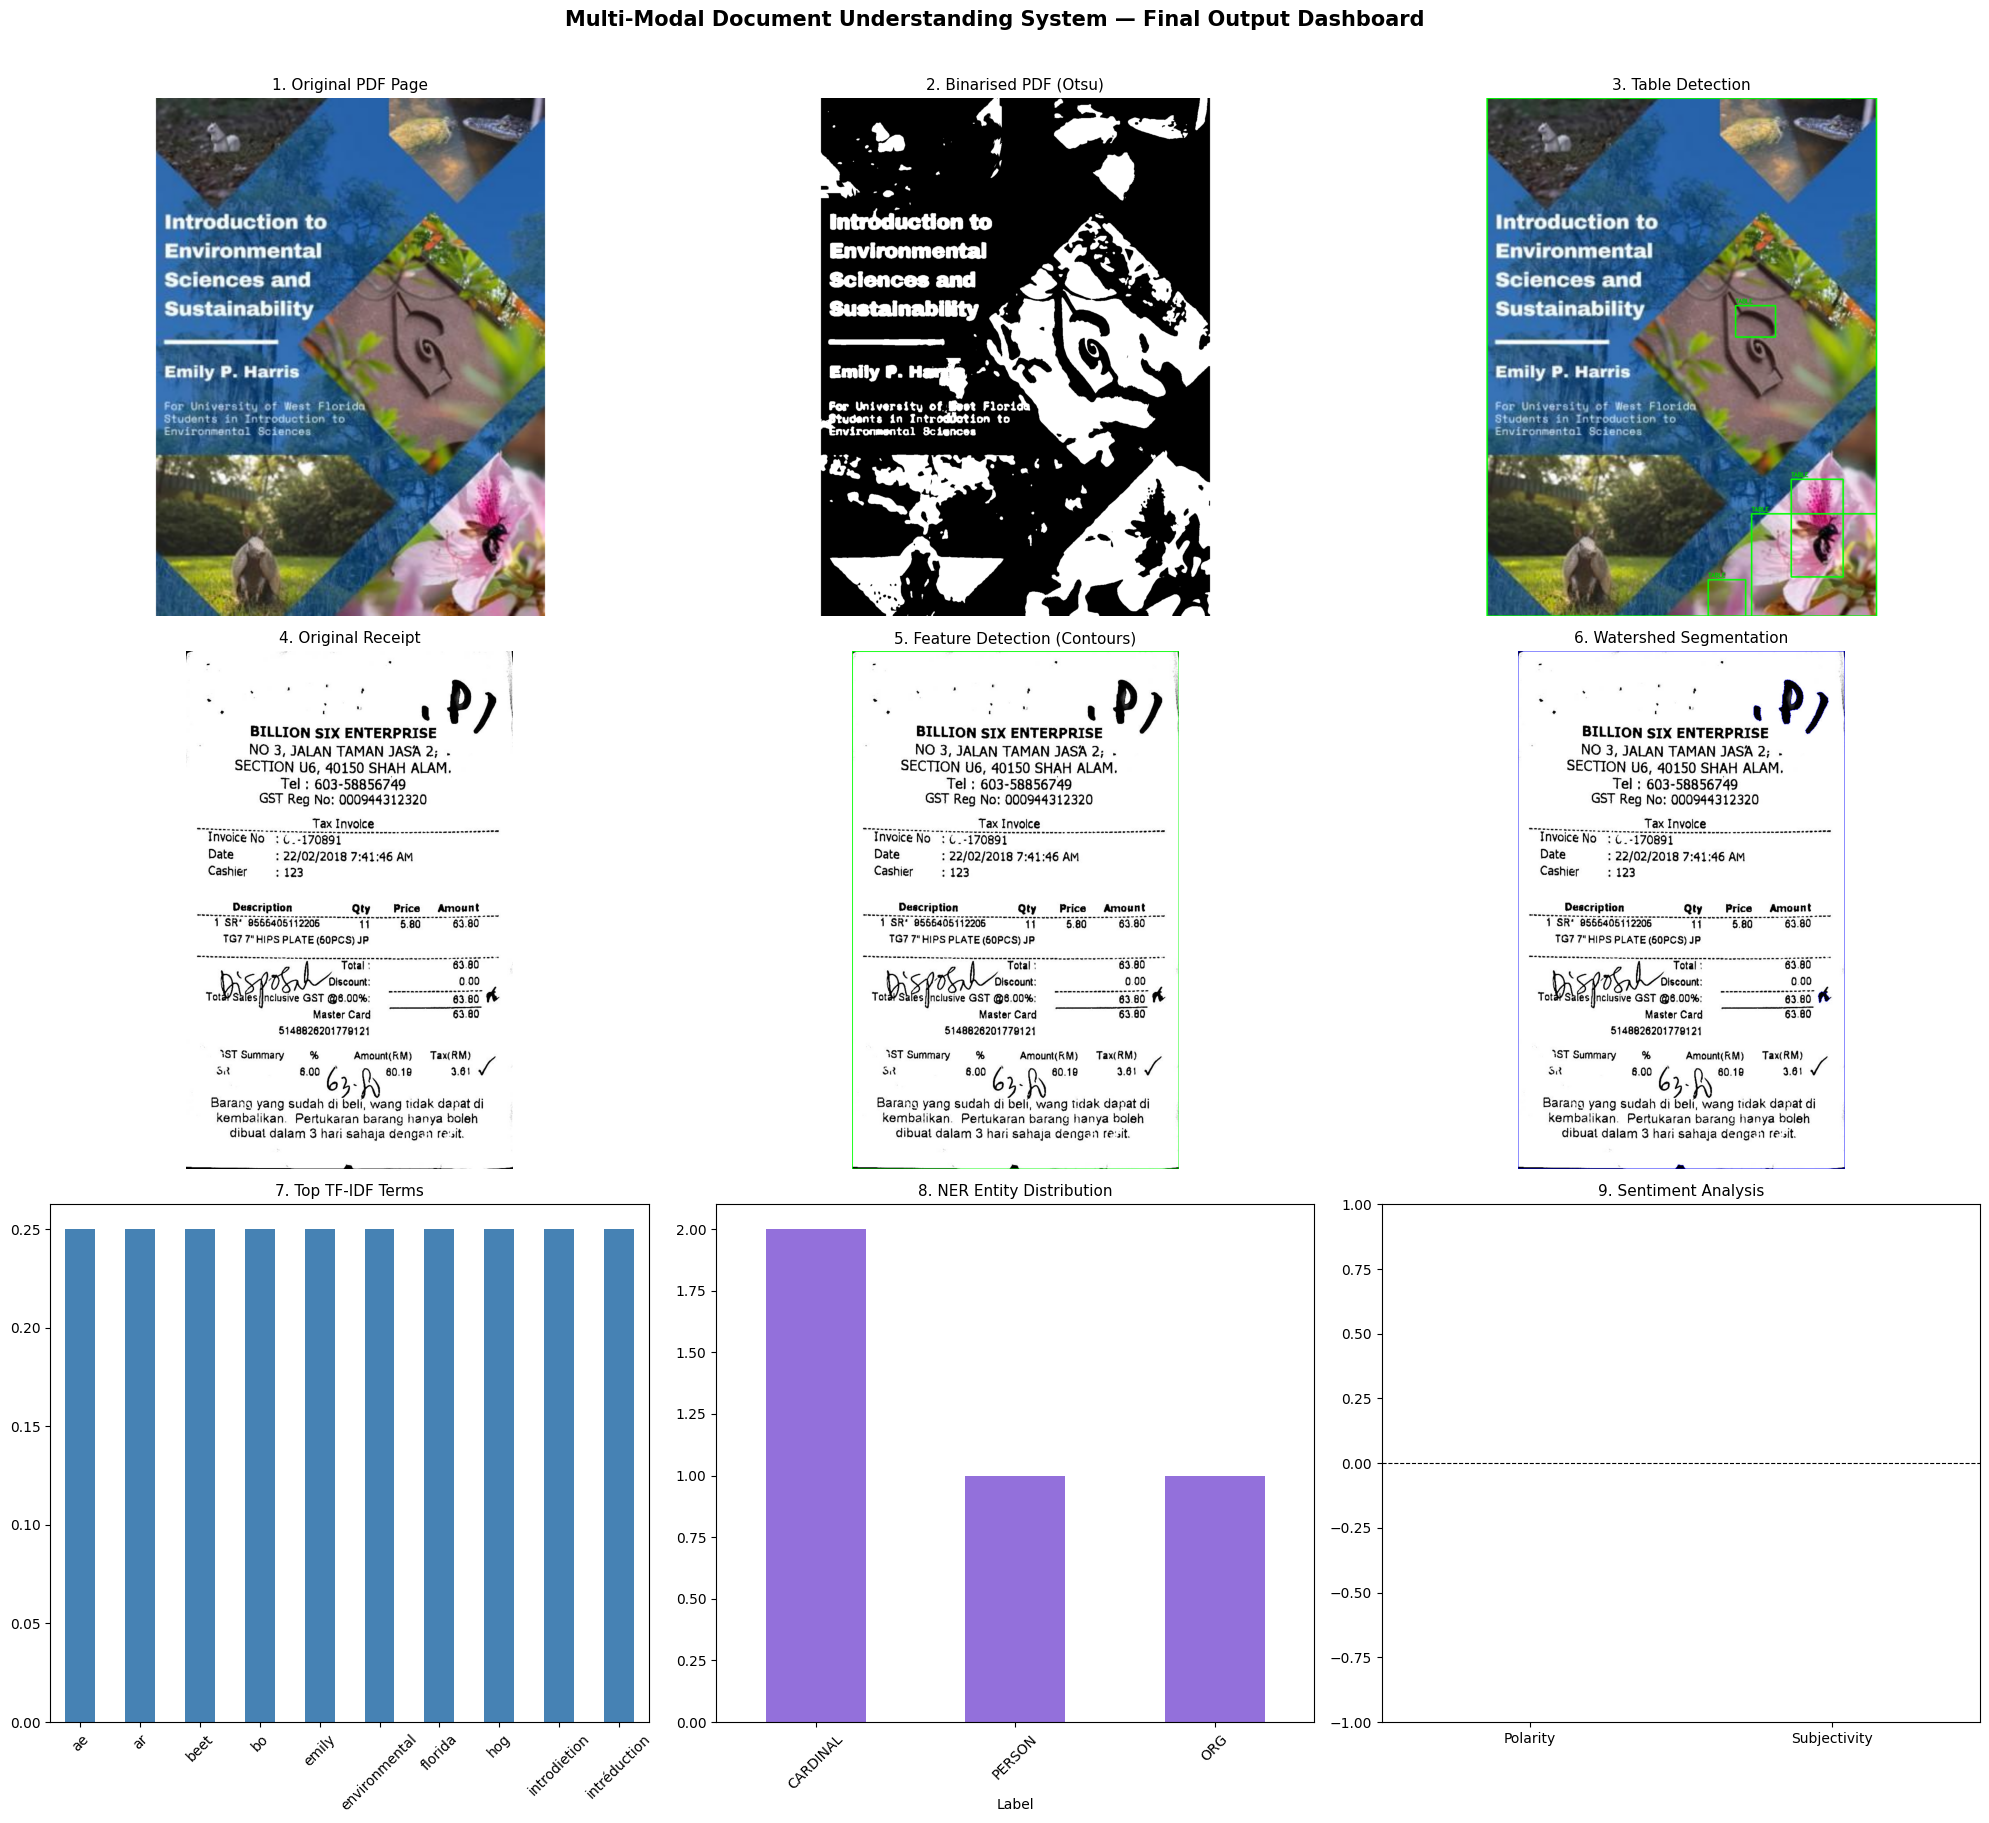


NARRATIVE INSIGHT SUMMARY

This multi-modal document understanding system successfully processed
two document types: a scanned academic PDF and a receipt image.

TEXT FINDINGS:
- OCR extracted 173 characters from the PDF using Tesseract
  with preprocessing (CLAHE + Otsu binarisation) to improve accuracy.
- After tokenisation, stemming and lemmatisation, 16
  meaningful tokens remained from 24 original tokens.
- TF-IDF and Bag-of-Words identified the most significant terms.
- RAKE extracted 0 key phrases, with top phrase: 'N/A'.
- spaCy NER found 4 named entities across multiple categories.
- Sentiment analysis classified the document as N/A
  (polarity: 0.000, subjectivity: 0.000).

IMAGE FINDINGS:
- OpenCV preprocessing (grayscale, denoising, CLAHE, thresholding)
  significantly improved image quality for both documents.
- Contour detection identified 1 visual regions
  (text blocks, figures, table regions).
- Connected components found 231 distinct segments.
- Watershed algorithm i

In [27]:
# CELL 17 — Final Output Dashboard
# Presents a comprehensive visual summary of all pipeline stages:
#   Row 1: Document preprocessing pipeline (PDF)
#   Row 2: Image analysis results (receipt)
#   Row 3: NLP insights
# All results are shown side by side for easy comparison.


fig, axes = plt.subplots(3, 3, figsize=(20, 18))

# Row 1 — PDF pipeline
axes[0, 0].imshow(pdf_image)
axes[0, 0].set_title("1. Original PDF Page", fontsize=11)
axes[0, 0].axis("off")

axes[0, 1].imshow(binary_pdf, cmap="gray")
axes[0, 1].set_title("2. Binarised PDF (Otsu)", fontsize=11)
axes[0, 1].axis("off")

axes[0, 2].imshow(table_vis)
axes[0, 2].set_title("3. Table Detection", fontsize=11)
axes[0, 2].axis("off")

# Row 2 — Receipt pipeline
axes[1, 0].imshow(receipt_rgb)
axes[1, 0].set_title("4. Original Receipt", fontsize=11)
axes[1, 0].axis("off")

axes[1, 1].imshow(contour_img)
axes[1, 1].set_title("5. Feature Detection (Contours)", fontsize=11)
axes[1, 1].axis("off")

axes[1, 2].imshow(cv2.cvtColor(receipt_bgr, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title("6. Watershed Segmentation", fontsize=11)
axes[1, 2].axis("off")

# Row 3 — NLP insights
tfidf_df.head(10).plot(kind="bar", ax=axes[2, 0], legend=False, color="steelblue")
axes[2, 0].set_title("7. Top TF-IDF Terms", fontsize=11)
axes[2, 0].tick_params(axis="x", rotation=45)

if not entities_df.empty:
    entities_df["Label"].value_counts().plot(
        kind="bar", ax=axes[2, 1], color="mediumpurple", legend=False
    )
axes[2, 1].set_title("8. NER Entity Distribution", fontsize=11)
axes[2, 1].tick_params(axis="x", rotation=45)

# Sentiment gauge
categories = ["Polarity", "Subjectivity"]
values = [pdf_polarity, pdf_subjectivity]
colors = ["green" if v > 0 else "red" for v in values]
axes[2, 2].bar(categories, values, color=colors)
axes[2, 2].set_title("9. Sentiment Analysis", fontsize=11)
axes[2, 2].set_ylim(-1, 1)
axes[2, 2].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle(
    "Multi-Modal Document Understanding System — Final Output Dashboard",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# ============================================================
# NARRATIVE INSIGHT SUMMARY
# ============================================================
print("\n" + "=" * 65)
print("NARRATIVE INSIGHT SUMMARY")
print("=" * 65)
print(f"""
This multi-modal document understanding system successfully processed
two document types: a scanned academic PDF and a receipt image.

TEXT FINDINGS:
- OCR extracted {len(pdf_text)} characters from the PDF using Tesseract
  with preprocessing (CLAHE + Otsu binarisation) to improve accuracy.
- After tokenisation, stemming and lemmatisation, {len(preprocess_results['filtered'])}
  meaningful tokens remained from {len(preprocess_results['tokens'])} original tokens.
- TF-IDF and Bag-of-Words identified the most significant terms.
- RAKE extracted {len(top_phrases)} key phrases, with top phrase: '{top_phrases[0] if top_phrases else 'N/A'}'.
- spaCy NER found {len(entities_df) if not entities_df.empty else 0} named entities across multiple categories.
- Sentiment analysis classified the document as {tone}
  (polarity: {pdf_polarity:.3f}, subjectivity: {pdf_subjectivity:.3f}).

IMAGE FINDINGS:
- OpenCV preprocessing (grayscale, denoising, CLAHE, thresholding)
  significantly improved image quality for both documents.
- Contour detection identified {len(features_df) if not features_df.empty else 0} visual regions
  (text blocks, figures, table regions).
- Connected components found {num_labels} distinct segments.
- Watershed algorithm identified {len(np.unique(markers))} regions with precise boundaries.
- Table detection found {len(table_regions)} potential table structure(s) in the PDF.
- Signature detection identified {len(signature_candidates)} candidate region(s).

INTEGRATION:
- Text references to visual elements: {len(text_references)} found.
- Document complexity score: {complexity_score:.1f}/10.
""")
print("=" * 65)
print("Pipeline complete. All components executed successfully.")

In [26]:
# REFERENCES

# OpenCV Documentation — https://docs.opencv.org/  
# (Used in: grayscale, denoising, thresholding, CLAHE, edge detection, contours, morphology, connected components, feature detection)

# Tesseract OCR Documentation — https://tesseract-ocr.github.io/  
# (Used in: OCR engine, image_to_string, image_to_data)

# NLTK Documentation — https://www.nltk.org/ 
# (Used in: tokenisation, stopwords, stemming, lemmatisation)

# Scikit-learn Documentation — https://scikit-learn.org/  
# (Used in: TF-IDF, Bag-of-Words)

# spaCy Documentation — https://spacy.io/  
# (Used in: Named Entity Recognition)

# Reference: TextBlob Documentation — https://textblob.readthedocs.io/  
# (Used in: sentiment analysis)

### AI Tools Used During Development
# ChatGPT (OpenAI).  
# (Used as an assistant for debugging, structuring the notebook, and improving explanations.)

# Claude (Anthropic).  
# (Used as a secondary assistant for refining text, validating logic, and improving clarity.)